Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split , GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

Data Collection and PreProcessing

In [2]:
# load the dataset to a pandas dataframe
dataset = pd.read_csv("/content/Rainfall.csv")

In [3]:
dataset.shape

(366, 12)

In [4]:
dataset.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [5]:
dataset['rainfall'].value_counts()

,count
rainfall,
yes,249
no,117


In [6]:
dataset["day"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [8]:
# remove extra spaces in all coloums
dataset.columns = dataset.columns.str.strip()

In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temparature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    object 
 9   sunshine       366 non-null    float64
 10  winddirection  365 non-null    float64
 11  windspeed      365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [10]:
dataset = dataset.drop(columns=["day"])

In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pressure       366 non-null    float64
 1   maxtemp        366 non-null    float64
 2   temparature    366 non-null    float64
 3   mintemp        366 non-null    float64
 4   dewpoint       366 non-null    float64
 5   humidity       366 non-null    int64  
 6   cloud          366 non-null    int64  
 7   rainfall       366 non-null    object 
 8   sunshine       366 non-null    float64
 9   winddirection  365 non-null    float64
 10  windspeed      365 non-null    float64
dtypes: float64(8), int64(2), object(1)
memory usage: 31.6+ KB


In [12]:
# Checking the number of missing values
dataset.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,1


In [13]:
dataset['winddirection'].unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [14]:
# handle the missing values
dataset['winddirection'] = dataset['winddirection'].fillna(dataset['winddirection'].mode()[0])
dataset['windspeed'] = dataset['windspeed'].fillna(dataset['windspeed'].median())

In [15]:
dataset.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,0


In [16]:
# replacing the values

dataset['rainfall'] = dataset['rainfall'].replace({"yes":1,"no":0})

/tmp/ipykernel_1539/2282409906.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['rainfall'] = dataset['rainfall'].replace({"yes":1,"no":0})


In [17]:
dataset["rainfall"].value_counts()

,count
rainfall,
1,249
0,117


In [18]:
dataset.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


In [19]:
dataset.shape

(366, 11)

In [20]:
# setting plot style for all the plots

sns.set(style="whitegrid")


In [21]:
dataset.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.534153
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.056054
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


In [22]:
dataset.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

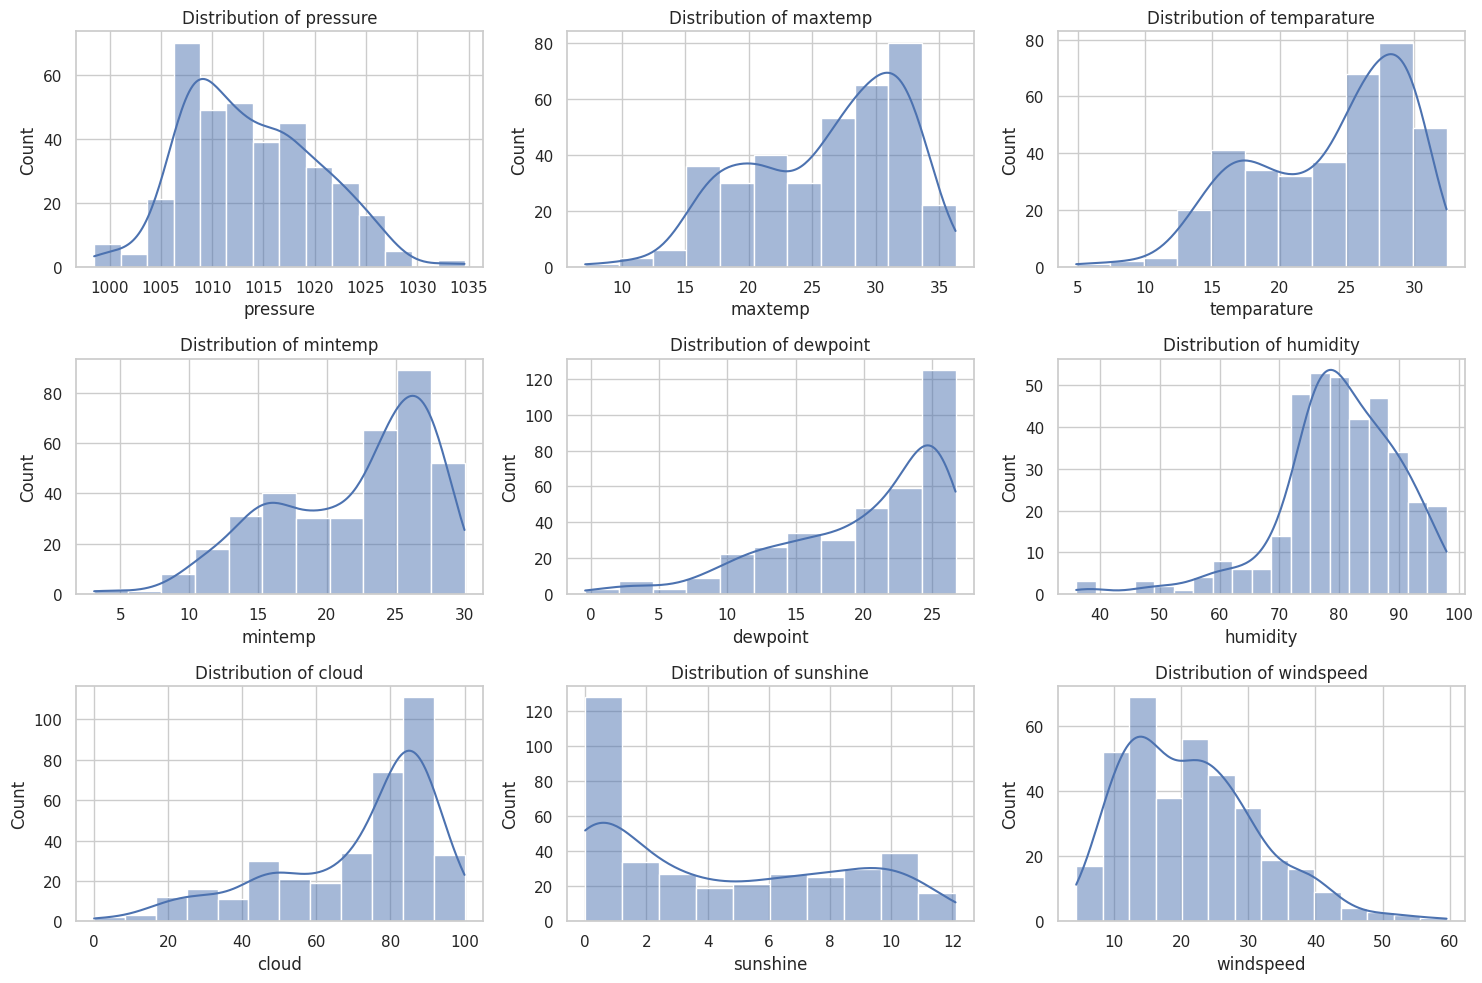

In [23]:
plt.figure(figsize=(15,10))

for i , column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine','windspeed'],1):
  plt.subplot(3,3,i)
  sns.histplot(dataset[column],kde=True)
  plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()


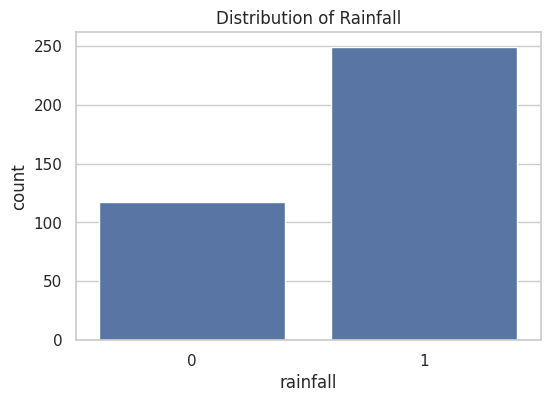

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="rainfall",data=dataset)
plt.title("Distribution of Rainfall")
plt.show()

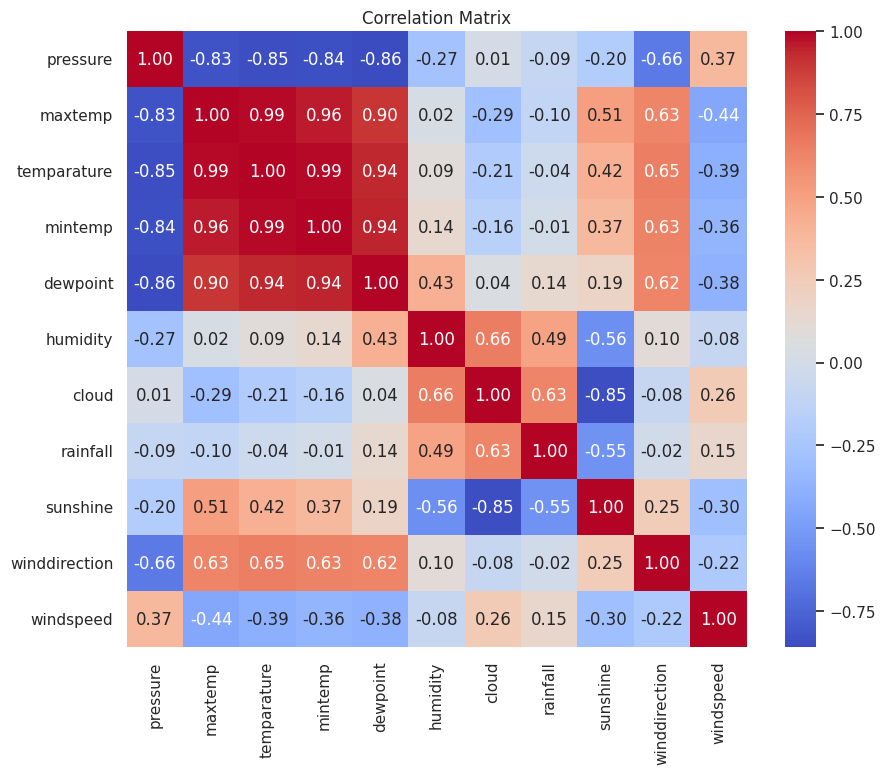

In [25]:
# correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(dataset.corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

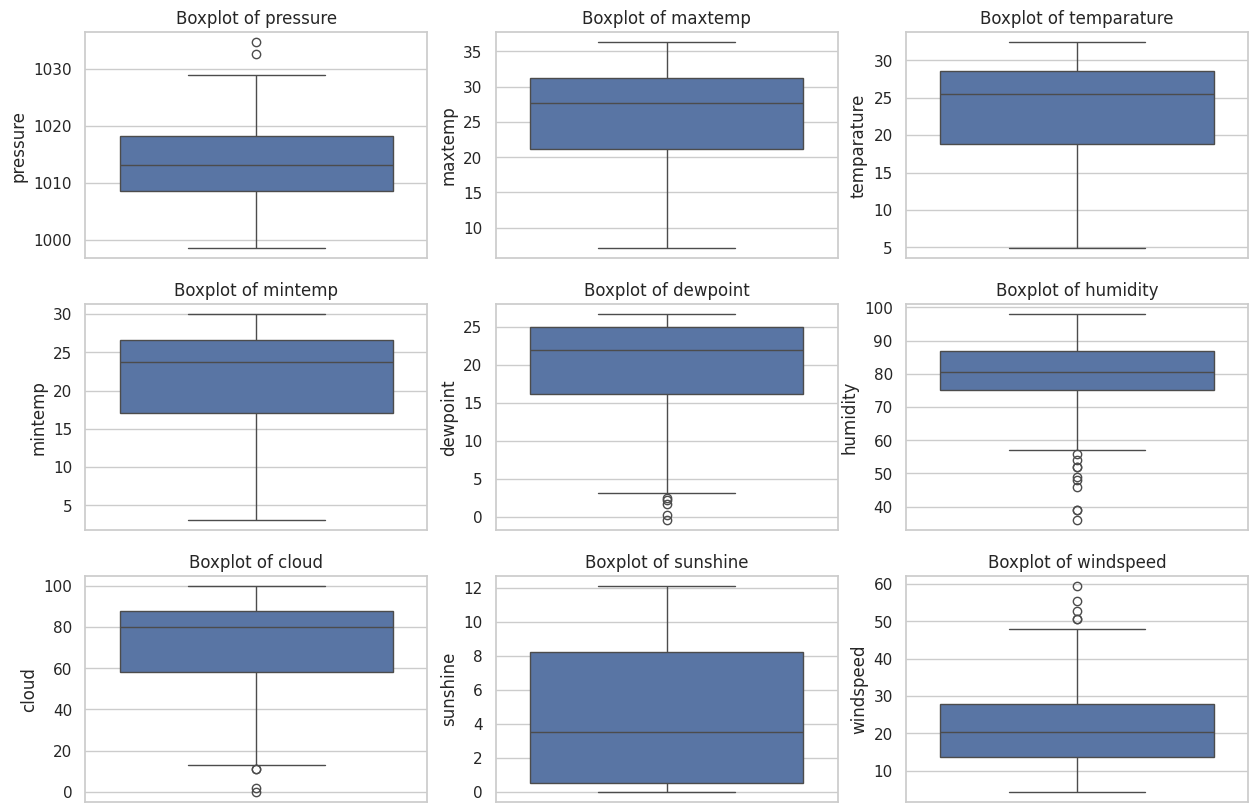

In [26]:
plt.figure(figsize=(15,10))

for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity','cloud', 'sunshine','windspeed'],1):
  plt.subplot(3,3,i)
  sns.boxplot(dataset[column])
  plt.title(f"Boxplot of {column}")

# plt.tight_layout()
plt.show()

**Data Preprocessing**

In [27]:
# drop highly correlated columns
dataset = dataset.drop(columns=['maxtemp', 'temparature', 'mintemp'])

In [28]:
dataset.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [29]:
dataset.shape

(366, 8)

In [30]:
print(dataset["rainfall"].value_counts())

rainfall
1    249
0    117
Name: count, dtype: int64


In [31]:
# separate majority and minority class
df_majority = dataset[dataset["rainfall"]==1]
df_minority = dataset[dataset["rainfall"]==0]

In [32]:
print(df_majority.shape)
print(df_minority.shape)

(249, 8)
(117, 8)


In [33]:
# downsample majority class to match minority class
df_majority_downsample = resample(df_majority,replace= False,n_samples=len(df_minority),random_state=42)

In [34]:
print(df_majority_downsample.shape)

(117, 8)


In [35]:
df_downsample = pd.concat([df_majority_downsample,df_minority])

In [36]:
df_downsample.shape

(234, 8)

In [37]:
df_downsample.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
188,1005.9,25.6,77,53,1,10.5,270.0,11.3
9,1017.5,15.5,85,91,1,0.0,70.0,37.7
137,1012.3,20.1,80,86,1,0.3,80.0,39.5
89,1018.3,16.3,79,89,1,2.4,40.0,14.8
157,1008.8,24.7,91,80,1,2.2,20.0,11.2


In [38]:
df_downsample["rainfall"].value_counts()

,count
rainfall,
1,117
0,117


In [39]:
# shuffling the final dataframe
df_downsample = df_downsample.sample(frac=1,random_state=42).reset_index(drop=True)

In [40]:
df_downsample.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1022.2,14.1,78,90,1,0.0,30.0,28.5
1,1013.4,19.5,69,17,0,10.5,70.0,12.4
2,1006.1,24.4,74,27,0,10.8,220.0,8.7
3,1007.6,24.8,85,84,1,1.8,70.0,34.8
4,1021.2,8.4,66,18,0,10.1,20.0,24.4


In [41]:
# split the features and target as X and Y
X = df_downsample.drop(columns=["rainfall"])
Y = df_downsample["rainfall"]

In [42]:
print(X.shape)
print(Y.shape)

(234, 7)
(234,)


In [43]:
#  splitting the data into training data and test data
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

**Model Training**

In [44]:
rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators":[50,100,200],
    "max_features":["sqrt","log2"],
    "max_depth":[None,10,20,30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [45]:
# Hypertuning using GridSearch CV
grid_search_rf = GridSearchCV(estimator=rf_model,param_grid=param_grid_rf,cv=5,n_jobs=-1,verbose=2)
grid_search_rf.fit(X_train,Y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [46]:
best_rf_model = grid_search_rf.best_estimator_
print("best parameter for Random forest: ",grid_search_rf.best_params_)

best parameter for Random forest:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}


In [47]:
print(best_rf_model)

RandomForestClassifier(min_samples_split=10, n_estimators=50, random_state=42)


**Model Evaluation**

In [48]:
cv_scores = cross_val_score(best_rf_model,X_train,Y_train,cv=5)
print("Cross Validation Scores: ",cv_scores,2)
print("Mean cross validation scores: ",np.mean(cv_scores))

Cross Validation Scores:  [0.68421053 0.81578947 0.83783784 0.83783784 0.91891892] 2
Mean cross validation scores:  0.818918918918919


In [49]:
# test set performance
Y_pred = best_rf_model.predict(X_test)

print("Test set accuracy: ",accuracy_score(Y_test,Y_pred))
print("Test set confusion matrix:\n",confusion_matrix(Y_test,Y_pred))
print("Classification report:\n",classification_report(Y_test,Y_pred))


Test set accuracy:  0.7446808510638298
Test set confusion matrix:
 [[17  7]
 [ 5 18]]
Classification report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74        24
           1       0.72      0.78      0.75        23

    accuracy                           0.74        47
   macro avg       0.75      0.75      0.74        47
weighted avg       0.75      0.74      0.74        47



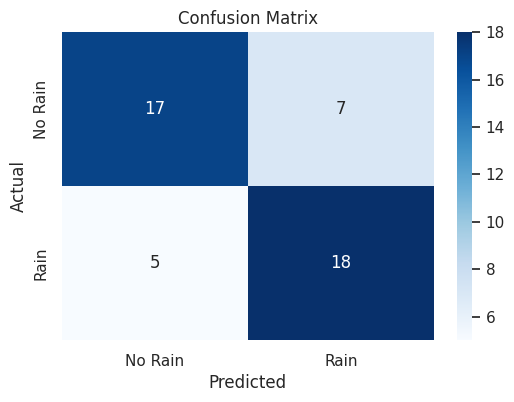

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, best_rf_model.predict(X_test))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Prediction on unknown data**

In [51]:
X_train.columns

Index(['pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine',
       'winddirection', 'windspeed'],
      dtype='object')

In [52]:
input_data =[1015.9,19.9,95,81,0.0,40,13.7]

input_df = pd.DataFrame([input_data],columns=['pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine','winddirection', 'windspeed'])

prediction = best_rf_model.predict(input_df)

print(f"Prediction result: {"Rainfall" if prediction[0]==1 else "No Rainfall"}")
print("Prediction result:","Rainfall" if prediction[0]==1 else "No Rainfall")

Prediction result: Rainfall
Prediction result: Rainfall


In [53]:
print(prediction)

[1]


In [54]:
import pickle
with open('rainfall_rf_model.pkl', 'wb') as file:
    pickle.dump(best_rf_model, file)